In [ ]:
cnn(convolutional neural network):
it is mainly used to work with the images

model architecture of cnn:

convolutional layers:
these layers will help to detect the shape,color,size,texture,edges etc

pooling layers:
which helps to reduce the size

flatten layers:
it helps to convert the images into vectors

fully connected layers:
the final prediction output layer

In [ ]:
------------THIS SYSTEM CAN BE USED FOR RECOGNIZING HANDWRITTEN DIGITS IN A CHEQUE CLEARING SYSTEM USED IN BANKS------------------

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


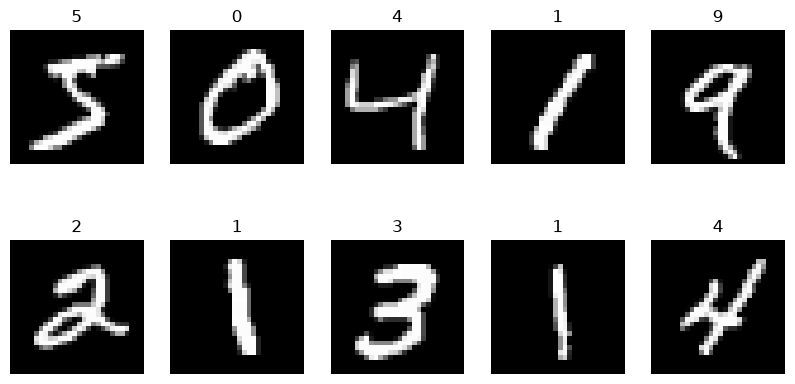

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i],cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")

plt.show()

In [4]:
X_train = X_train / 255.0
X_test = X_test / 255.0


In [5]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [6]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [7]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation="relu",input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(10,activation="softmax"))

d:\Users\Hp\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.9191 - loss: 0.2662 - val_accuracy: 0.9806 - val_loss: 0.0638
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9733 - loss: 0.0900 - val_accuracy: 0.9863 - val_loss: 0.0468
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9805 - loss: 0.0645 - val_accuracy: 0.9880 - val_loss: 0.0414
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9842 - loss: 0.0529 - val_accuracy: 0.9877 - val_loss: 0.0403
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9862 - loss: 0.0453 - val_accuracy: 0.9902 - val_loss: 0.0367
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.9881 - loss: 0.0390 - val_accuracy: 0.9898 - val_loss: 0.0336
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9897 - loss: 0.0317 - val_accuracy: 0.9916 - val_loss: 0.0309
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9905 - loss: 0.0305 - 

In [10]:
loss,accuracy=model.evaluate(X_test,y_test)

print("Accuracy:",accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9915 - loss: 0.0273
Accuracy: 0.9915000200271606


In [11]:
prediction=model.predict(X_test)

digit=np.argmax(prediction[0])

print("Predicted :",digit)
print("Actual :",np.argmax(y_test[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predicted : 7
Actual : 7


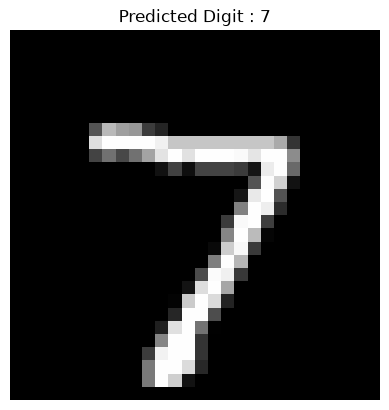

In [12]:
plt.imshow(X_test[0].reshape(28,28),cmap="gray")
plt.title(f"Predicted Digit : {digit}")
plt.axis("off")
plt.show()

In [18]:
model.save("digit_recognition_model.keras")

In [19]:
from tensorflow.keras.models import load_model

model = load_model("digit_recognition_model.keras")

d:\Users\Hp\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(store)


In [20]:
from PIL import Image

image = Image.open("sample_digit_5.png").convert("L")
image = image.resize((28,28))

image = np.array(image)
image = image / 255.0
image = image.reshape(1,28,28,1)

prediction = model.predict(image)

print("Predicted Digit :", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
Predicted Digit : 5
